In [1]:
# ================================
# CELL 1: Import Libraries & Load Data
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load our dataset
df = pd.read_csv('data/products.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (30, 6)

First 5 rows:


,id,name,category,description,rating,reviews
0,1,boAt Rockerz 450 Bluetooth Headphone,Electronics,Wireless bluetooth headphone with 15 hours bat...,4.2,12000
1,2,Sony WH-1000XM5 Noise Cancelling,Electronics,Industry leading noise cancelling wireless hea...,4.7,8500
2,3,JBL Tune 510BT Wireless,Electronics,Wireless on ear headphone with powerful JBL pu...,4.1,9200
3,4,Sennheiser CX 80S Earphone,Electronics,In ear wired earphone with one button smart re...,3.9,4300
4,5,Noise ColorFit Pro 4 Smartwatch,Electronics,Smartwatch with 1.72 inch display SpO2 heart r...,4.0,15000


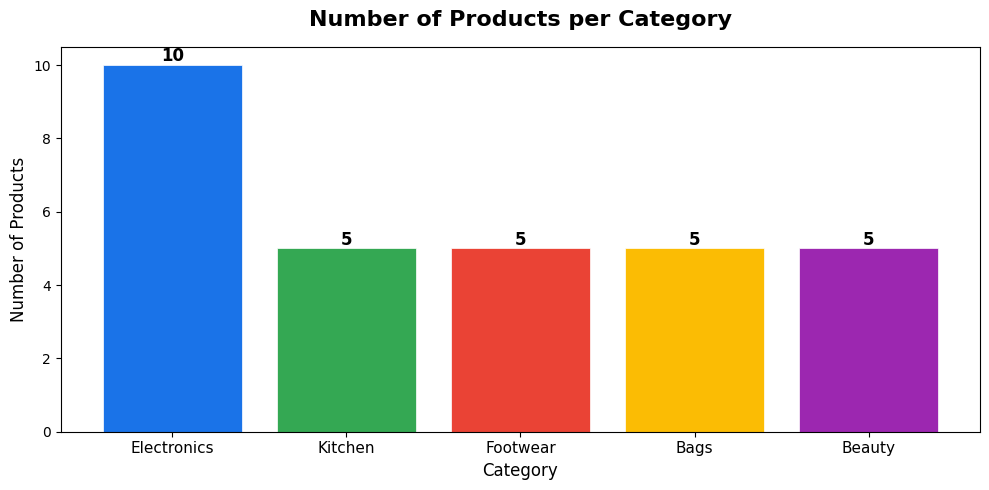

Categories in dataset: ['Electronics', 'Kitchen', 'Footwear', 'Bags', 'Beauty']


In [2]:
# ================================
# CELL 2: Products per Category
# ================================
plt.figure(figsize=(10, 5))

category_counts = df['category'].value_counts()

colors = ['#1a73e8', '#34a853', '#ea4335', '#fbbc04', '#9c27b0']
plt.bar(category_counts.index, category_counts.values, color=colors, edgecolor='white', linewidth=0.5)

plt.title('Number of Products per Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(fontsize=11)

for i, v in enumerate(category_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("Categories in dataset:", list(category_counts.index))

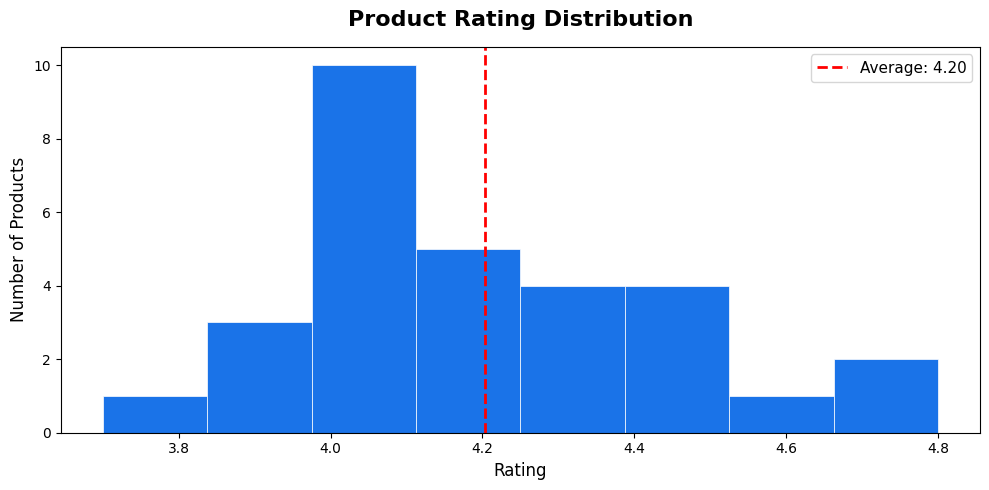

Average Rating: 4.2
Highest Rating: 4.8
Lowest Rating: 3.7


In [3]:
# ================================
# CELL 3: Rating Distribution
# ================================
plt.figure(figsize=(10, 5))

plt.hist(df['rating'], bins=8, color='#1a73e8', edgecolor='white', linewidth=0.5)

plt.title('Product Rating Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.axvline(df['rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Average: {df['rating'].mean():.2f}")
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Average Rating:", round(df['rating'].mean(), 2))
print("Highest Rating:", df['rating'].max())
print("Lowest Rating:", df['rating'].min())

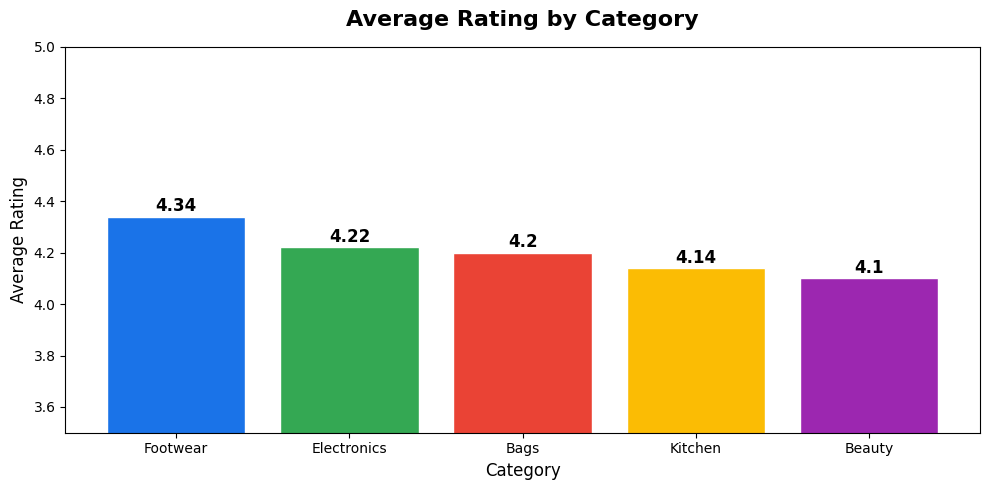


Average rating per category:
category
Footwear       4.34
Electronics    4.22
Bags           4.20
Kitchen        4.14
Beauty         4.10
Name: rating, dtype: float64


In [4]:
# ================================
# CELL 4: Average Rating by Category
# ================================
plt.figure(figsize=(10, 5))

avg_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)

colors = ['#1a73e8', '#34a853', '#ea4335', '#fbbc04', '#9c27b0']
bars = plt.bar(avg_rating.index, avg_rating.values, color=colors, edgecolor='white')

plt.title('Average Rating by Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3.5, 5.0)

for i, v in enumerate(avg_rating.values):
    plt.text(i, v + 0.02, str(round(v, 2)), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\nAverage rating per category:")
print(avg_rating)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\manis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Dataset loaded: 30 products, 6 columns
After cleaning: 30 products remaining
Feature engineering done!

Sample combined_text:
boat rockerz bluetooth headphone electronics wireless bluetooth headphone hours battery life deep bass foldable design
TF-IDF Matrix Shape: (30, 239)
→ 30 products x 239 unique words

Similarity Matrix Shape: (30, 30)
→ 30x30 = every product vs every product


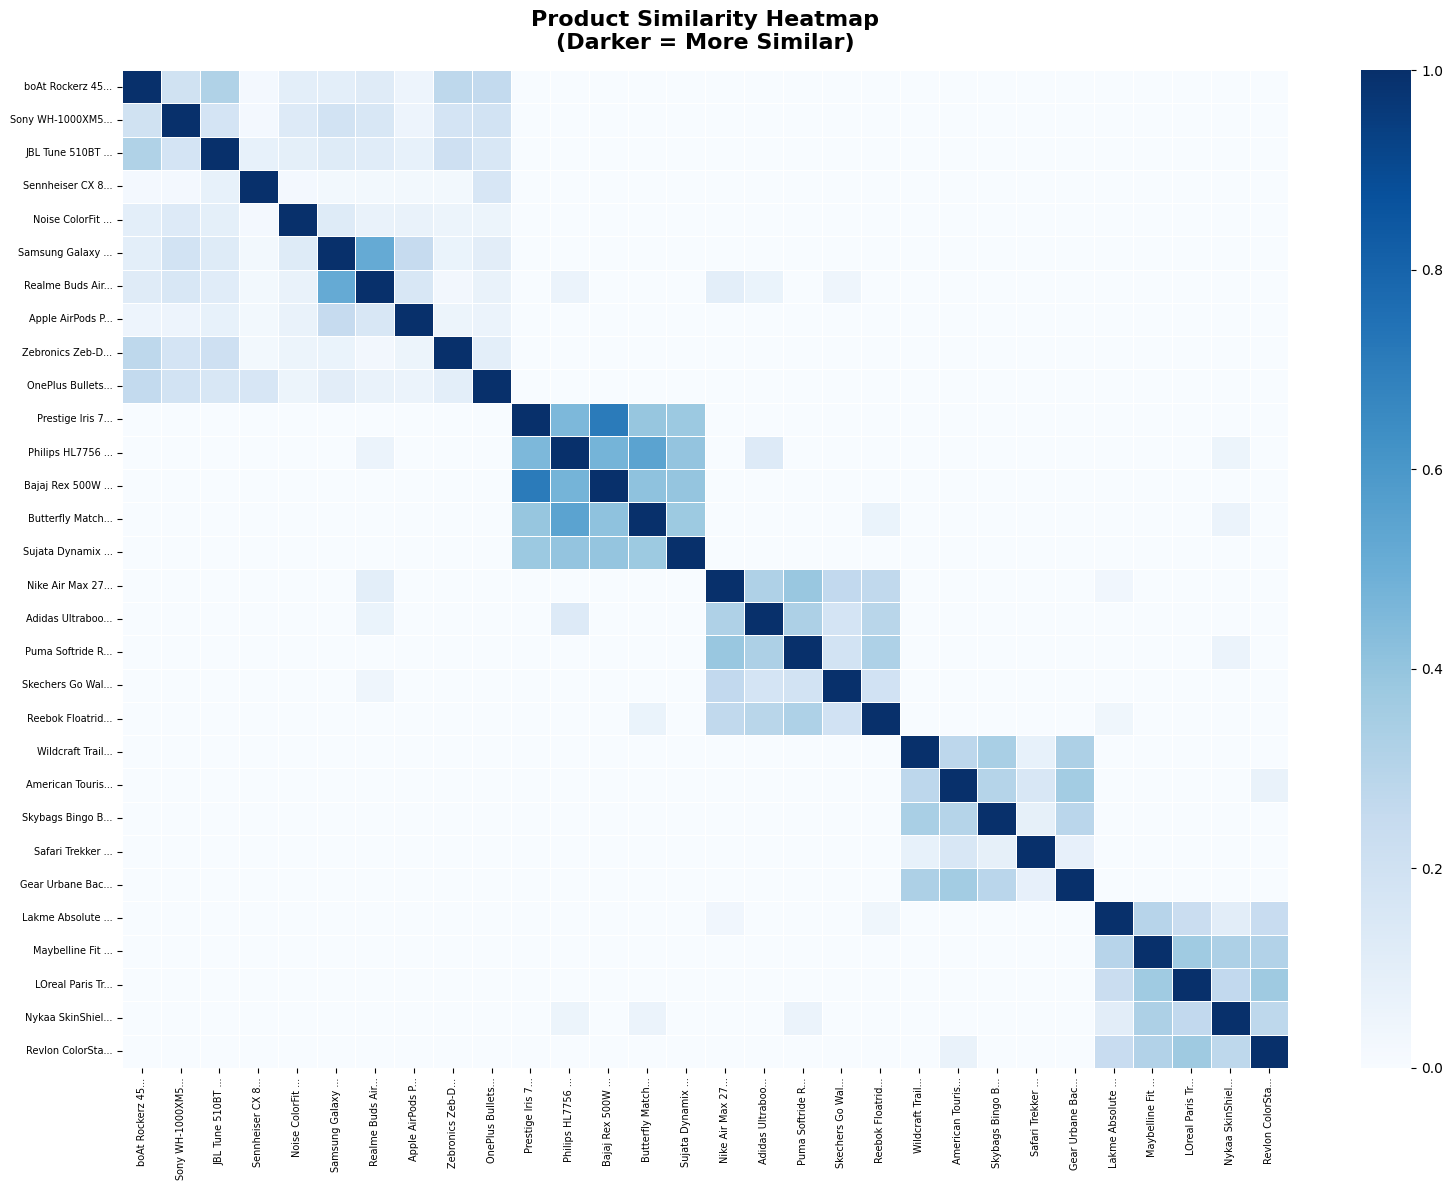

Heatmap shows similarity between all 30 products!
Diagonal is always 1.0 (product is 100% similar to itself)


In [5]:
# ================================
# CELL 5: Similarity Heatmap
# This is the most impressive visualization!
# Shows how similar every product is to every other product
# ================================
import sys
sys.path.insert(0, '.')

from data_preprocessing import load_data, clean_data, create_features
from nlp_engine import build_tfidf_matrix, build_similarity_matrix

# Build everything
df2 = load_data()
df2 = clean_data(df2)
df2 = create_features(df2)
tfidf, tfidf_matrix = build_tfidf_matrix(df2)
similarity_matrix = build_similarity_matrix(tfidf_matrix)

# Short names for display
short_names = [name[:15] + '...' if len(name) > 15 else name for name in df2['name']]

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    similarity_matrix,
    xticklabels=short_names,
    yticklabels=short_names,
    cmap='Blues',
    linewidths=0.5,
    annot=False
)

plt.title('Product Similarity Heatmap\n(Darker = More Similar)', 
          fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

print("Heatmap shows similarity between all 30 products!")
print("Diagonal is always 1.0 (product is 100% similar to itself)")
